In [27]:
import numpy as np
import math
import pandas as pd
import matplotlib.pyplot as plt

In [134]:
from math import log
import numpy as np

#Activation Function and Derivative
def sigmoid(x): return 1 / (1 + np.e**(-1*x))
def sigmoidPrime(x): return np.e**(-1*x) / ((1 + np.e**(-1*x))**2) 


#Some useful comversion functions
def ListtoVector(new_list):
    length = len(new_list)
    vec = np.arange(length)
    for i,v in enumerate(new_list):
        vec[i] = v
    return vec.reshape(length, 1)

def VectortoList(new_vec):
    length = (new_vec.size)
    reshaped = new_vec.reshape(1, length)
    new_list = list()
    for v in reshaped[0]:
        new_list.append(v)
    return new_list

#A function that setups your initial network including randomized weights, input is the form of a list of the number of neurons in each layer. e.g [784, x, y, 10] where x and y are the number of neurons in your hiddenn layers
def architecture(new_list):
    weights = list()
    biases = list()
    weights.append(None)
    biases.append(None)
    network_length = len(new_list)
    for c in range(network_length-1):
        weight_matrix = 2 * np.random.rand(new_list[c+1], new_list[c]) - 1
        bias_matrix = 2 * np.random.rand(new_list[c+1],1) - 1
        weights.append(weight_matrix)
        biases.append(bias_matrix)
    return weights, biases

#take in the CSVs and vectorize the output, would reccomend experimenting with to see exactly what happens
def read_file(file_name):
    toReturn = list()
    with open(file_name) as f:
        for line in f:
            image = line[0:len(line)-1].split(",")
            output = image.pop(0)
            in_vec = ListtoVector(image)
            out_vec = list()
            for c in range(10):
                if c == int(output):
                    out_vec.append(1)
                else:
                    out_vec.append(0)
            out_vec = ListtoVector(out_vec)
            toAppend = (in_vec,out_vec)
            toReturn.append(toAppend)
    return toReturn

#TODO A feed forward of the network where A_vec is the activation function, weights is a list of all the weight matrices, biases is a list of all the bias vectors, and inp is the input, return the output as a vector
def p_net(A_vec, weights, biases, inp):
    
    curr_val = inp
    
    for i in range(1, len(weights)):
        z = np.dot(weights[i], curr_val) + biases[i]
        output = A_vec(z)
        curr_val = output
        
    return curr_val

#TODO This is where you back propogate by calculating the deltas and updating the weights and biases, try different learning rates and see what works
def one_epoch(training, weights, biases):
    learning_rate = 0.01
    for x, y in training:
        # 1. Forward pass, store z and activations
        activations = [x]
        zs = []
        curr_a = x
        for i in range(1, len(weights)):
            z = np.dot(weights[i], curr_a) + biases[i]
            zs.append(z)
            curr_a = sigmoid(z)
            activations.append(curr_a)
        
        # 2. Backward pass - Output layer error
        delta = (activations[-1] - y) * sigmoidPrime(zs[-1])

        # Update output layer weights and biases
        weights[-1] -= learning_rate * np.dot(delta, activations[-2].T)
        biases[-1] -= learning_rate * delta

        # 3. Backpropagate error to hidden layers
        for l in range(2, len(weights)):
            z = zs[-l]
            sp = sigmoidPrime(z)
            delta = np.dot(weights[-l+1].T, delta) * sp
            weights[-l] -= learning_rate * np.dot(delta, activations[-l-1].T)
            biases[-l] -= learning_rate * delta
    return weights, biases

#TODO Run your model over some number of epochs should be at least 10 and display a graph that shows train and test accuracy on each Epoch
def evaluate(data, weights, biases):
    correct_preds = 0
    for x,y in data: 
        output = p_net(sigmoid, weights, biases, x)
        if np.argmax(output) == np.argmax(y):
            correct_preds += 1
            
    return (correct_preds / len(data))

def normalize(data):
    normalize_data = []
    for x,y in data:
        norm_x = x / 255
        normalize_data.append((norm_x, y))
    return normalize_data
        

In [136]:
training = read_file('mnist_train.csv')
testing = read_file('mnist_test.csv')

training_normal = normalize(training)
testing_normal = normalize(testing)

In [162]:
# Initialize the weights and biases
set_up = [784, 64,32,10]
weights, biases = architecture(set_up)

In [163]:
num_epochs = 30
train_accs = []
test_accs = []
y_preds = []
ys = []
weight_history = []
bias_history = []
for i in range(num_epochs):
    # weights, biases = one_epoch(training, weights, biases)
    weights_biases = one_epoch(training_normal, weights, biases)
    weight_history.append(weights)
    bias_history.append(biases)
    
    train_acc = evaluate(training_normal, weights, biases)
    train_accs.append(train_acc)
    
    test_acc = evaluate(testing_normal, weights, biases)
    test_accs.append(test_acc)

Text(0, 0.5, 'accuracy')

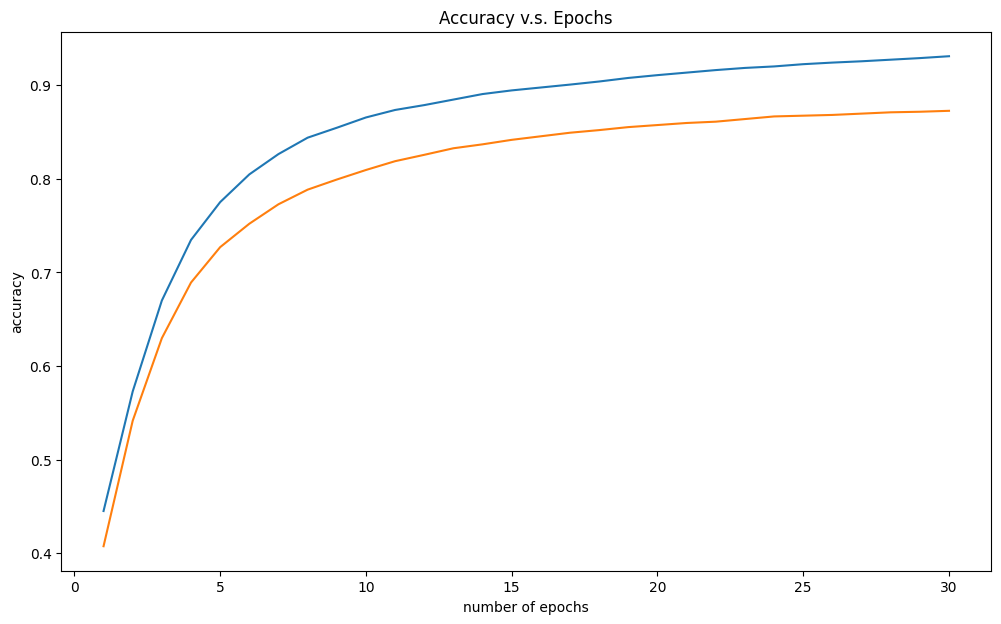

In [164]:
fig = plt.figure(figsize = (12,7))
plt.plot([i+1 for i in range(num_epochs)], train_accs)
plt.plot([i+1 for i in range(num_epochs)], test_accs)
plt.title('Accuracy v.s. Epochs')
plt.xlabel('number of epochs')
plt.ylabel('accuracy')